In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('../data/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [6]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [7]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [8]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
df = pd.get_dummies(df, columns=["sex", "smoker", "region"], drop_first=True)
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [10]:
bool_cols = ["sex_male", "smoker_yes", "region_northwest", "region_southeast", "region_southwest"]
df[bool_cols] = df[bool_cols].astype(int)

In [11]:
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   bmi               1338 non-null   float64
 2   children          1338 non-null   int64  
 3   charges           1338 non-null   float64
 4   sex_male          1338 non-null   int64  
 5   smoker_yes        1338 non-null   int64  
 6   region_northwest  1338 non-null   int64  
 7   region_southeast  1338 non-null   int64  
 8   region_southwest  1338 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 94.2 KB


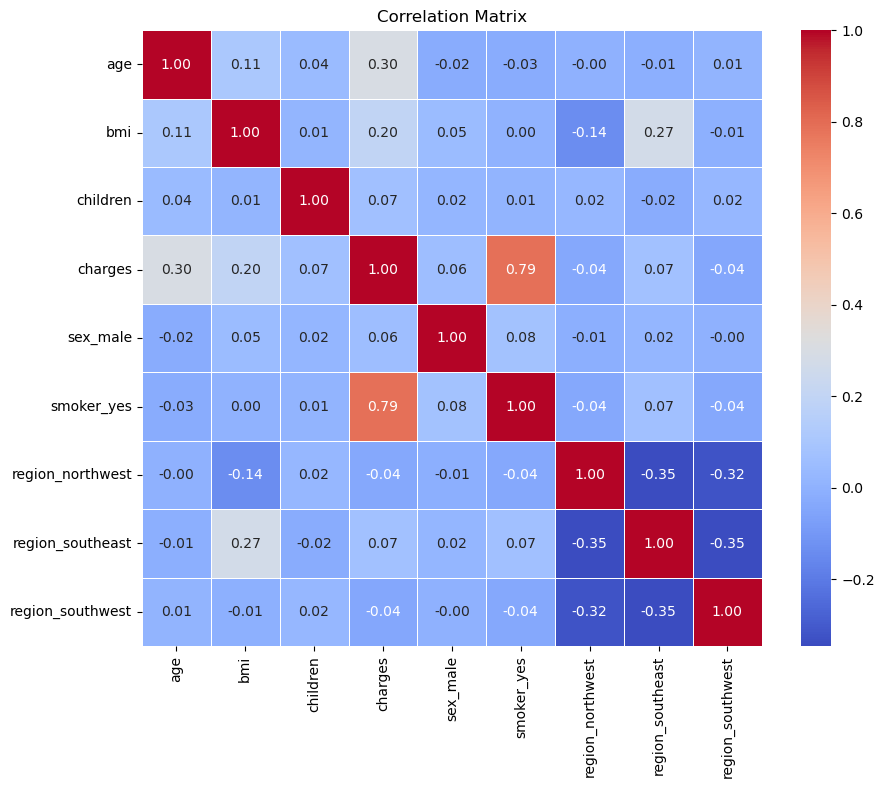

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

In [14]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import  GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error 
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

In [18]:
models_params = {
 
    "Linear Regression": {
        "model": LinearRegression(),
        "params": {}   
    },
 
    "Polynomial Regression": {
        "model": Pipeline([
            ("poly", PolynomialFeatures()),
            ("scaler", StandardScaler()),
            ("linear", LinearRegression())
        ]),
        "params": {
            "poly__degree": [2, 3]   
        }
    },
 
    "Ridge": {
        "model": Ridge(),
        "params": {
            "alpha": [0.01, 0.1, 1, 10, 50, 100, 200, 500]  
        }
    },
 
    "Lasso": {
        "model": Lasso(max_iter=100000),
        "params": {
            "alpha": [0.01, 0.1, 1, 10, 100, 200, 500, 1000]
        }
    },
 
    "ElasticNet": {
        "model": ElasticNet(max_iter=100000),
        "params": {
            "alpha": [0.001, 0.005, 0.01, 0.1, 1, 10],
            "l1_ratio": [0.05, 0.1, 0.2, 0.5, 0.8, 0.95]   
        }
    },
 
    "SVR": {
        "model": TransformedTargetRegressor(
            regressor=SVR(),
            transformer=StandardScaler()
        ),
        "params": {
            "regressor__kernel": ["linear", "rbf"],
            "regressor__C": [0.1, 1, 10, 100, 500, 1000, 5000],
            "regressor__gamma": ["scale", "auto"]
        }
    },
 
    "KNN": {
        "model": KNeighborsRegressor(),
        "params": {
            "n_neighbors": [3, 5, 7, 9, 11, 15],   
            "weights": ["uniform", "distance"],
            "metric": ["euclidean", "manhattan"] 
        }
    },
 
    "Decision Tree": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {
            "max_depth": [3, 5, 7, 10, 15, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4, 8] 
        }
    }
}

results = []
 
for name, mp in models_params.items():
 
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
 
    if len(mp["params"]) > 0:
        grid = GridSearchCV(
            estimator=mp["model"],    
            param_grid=mp["params"],    
            cv=5,                      
            scoring="r2",               
            n_jobs=-1                    
        )
        grid.fit(X_train_scaled, y_train)  
        best_model = grid.best_estimator_   
        best_params = grid.best_params_     
 
    else:
        best_model = mp["model"]
        best_model.fit(X_train_scaled, y_train)
        best_params = "No parameter"
 
    y_pred = best_model.predict(X_test_scaled)
 
    # Evaluation
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
 
    print(f"Best params: {best_params}")
    print(f"R2: {r2:.4f} | RMSE: {rmse:.2f} | MAE: {mae:.2f}")
 
    results.append({
        "Model": name,
        "Best Params": best_params,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })
 
results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
 
print("\n\nRESULTS:")
print(results_df.to_string(index=False))




Linear Regression
Best params: No parameter
R2: 0.7867 | RMSE: 5542.85 | MAE: 4023.65

Polynomial Regression
Best params: {'poly__degree': 2}
R2: 0.8750 | RMSE: 4243.21 | MAE: 2762.13

Ridge
Best params: {'alpha': 10}
R2: 0.7871 | RMSE: 5537.21 | MAE: 4036.41

Lasso
Best params: {'alpha': 100}
R2: 0.7878 | RMSE: 5528.51 | MAE: 4020.13

ElasticNet
Best params: {'alpha': 0.01, 'l1_ratio': 0.05}
R2: 0.7871 | RMSE: 5537.42 | MAE: 4035.80

SVR
Best params: {'regressor__C': 1, 'regressor__gamma': 'scale', 'regressor__kernel': 'rbf'}
R2: 0.8854 | RMSE: 4062.74 | MAE: 2298.61

KNN
Best params: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}
R2: 0.8592 | RMSE: 4504.02 | MAE: 2870.09

Decision Tree
Best params: {'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 2}
R2: 0.9009 | RMSE: 3777.89 | MAE: 2285.75


RESULTS:
                Model                                                                  Best Params       R2        RMSE         MAE
        Decision Tree 